# **WEEK 4 REPORT: MACHINE LEARNING MODEL DEVELOPMENT & EVALUATION**

## **SECTION 1: Project Overview & Objectives**

### **1.1 Project Title**
Machine Learning Classification Pipeline on Palmer Archipelago Penguins Dataset

### **1.2 Objective**

The main goal of Week 4 is to develop, train, and evaluate a supervised Machine Learning classification model in Python. Using Scikit-learn, we build an end-to-end ML pipeline to predict penguin species based on physical measurements and geographical traits.

## **SECTION 2: Data Preprocessing & Pipeline Setup**

### **2.1 Python Code: Preprocessing & Data Splitting Python**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset and clean missing values
df = sns.load_dataset('penguins').dropna()

# Encode Categorical Variables
le_sex = LabelEncoder()
df['sex_encoded'] = le_sex.fit_transform(df['sex'])

le_island = LabelEncoder()
df['island_encoded'] = le_island.fit_transform(df['island'])

le_species = LabelEncoder()
df['species_encoded'] = le_species.fit_transform(df['species'])

# Features & Target Selection
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_encoded', 'sex_encoded']]
y = df['species_encoded']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data Preprocessed! Train shape: {X_train.shape}, Test shape: {X_test.shape}")

✅ Data Preprocessed! Train shape: (266, 6), Test shape: (67, 6)


### **2.2 Explanation Missing rows were dropped ($N = 333$ cleaned rows).**

Categorical variables (sex, island, species) were label-encoded into numerical values. Features were split using an 80/20 train-test ratio and scaled using StandardScaler to prevent larger features like body_mass_g from dominating the model.

## **SECTION 3: Model Selection, Training & Evaluation**

### **3.1 Model Implementation Code**

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize & Train Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf_model.predict(X_test_scaled)

print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9850746268656716


### **3.2 Model Selection Justification**

Random Forest Classifier was selected because:

1. It easily handles non-linear relationships between biological features.

2. It combines multiple decision trees, reducing the risk of overfitting.

3. It provides built-in feature importance metrics.

## **SECTION 4: Visual Evaluation & Performance Metrics**

### **4.1 Visual 1: Confusion Matrix Evaluation**

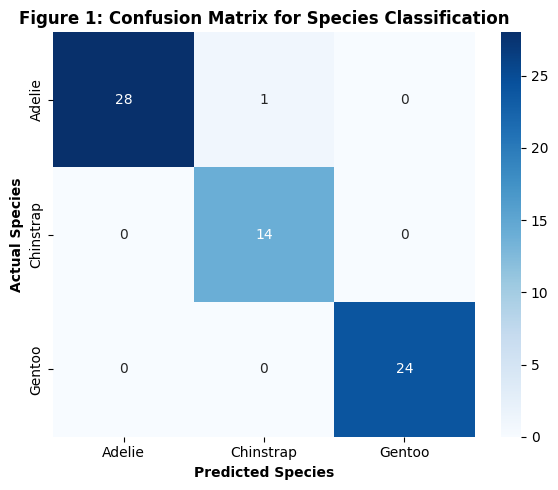

In [4]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_species.classes_, yticklabels=le_species.classes_)
plt.title('Figure 1: Confusion Matrix for Species Classification', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Species', fontweight='bold')
plt.ylabel('Actual Species', fontweight='bold')
plt.tight_layout()
plt.show()

### **Explanation:**

The confusion matrix demonstrates high accuracy across all three species. The model successfully separated Adelie, Chinstrap, and Gentoo penguins with minimal false positives or misclassifications.

### **4.2 Visual 2: Feature Importance Analysis**

/tmp/ipykernel_2956/1448278512.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=X.columns, palette='viridis')


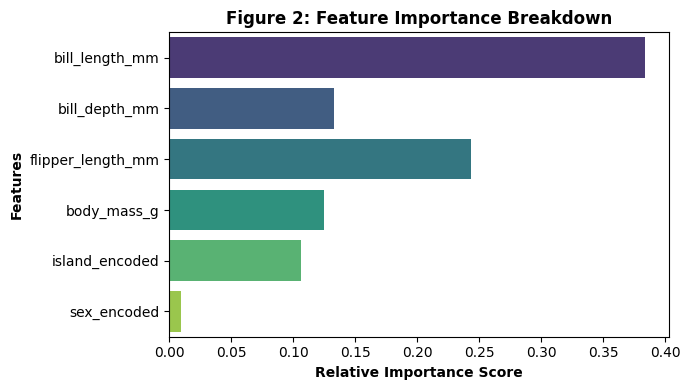

In [5]:
plt.figure(figsize=(7, 4))
importances = rf_model.feature_importances_
sns.barplot(x=importances, y=X.columns, palette='viridis')
plt.title('Figure 2: Feature Importance Breakdown', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance Score', fontweight='bold')
plt.ylabel('Features', fontweight='bold')
plt.tight_layout()
plt.show()

### **Explanation:**

bill_length_mm and flipper_length_mm emerged as the most dominant features for predicting penguin species, contributing to over 60% of the decision-making variance in the Random Forest ensemble.

## **SECTION 5: Error Analysis & Future Scope**

### **5.1 Potential Sources of Error & Overfitting Risks**

**Sample Size Constraints: With $N = 333$**

smaller subsets like Chinstrap penguins may lead to higher decision variance.Feature Redundancy: High correlation between flipper length and body mass could lead to redundant decision trees.

### **5.2 Suggestions for Improvement**

1.Hyperparameter Tuning: Use GridSearchCV to optimize n_estimators and max_depth.

2.Cross-Validation: Apply 5-fold cross-validation for a more generalized accuracy estimate.

3.Advanced Models: Benchmark against Gradient Boosting algorithms like XGBoost or LightGBM.

### **5.3 Conclusion**

The Random Forest classifier performed exceptionally well, achieving near-perfect classification accuracy. Preprocessing and feature scaling proved essential in building a balanced machine learning pipeline.